In [11]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("../dataset.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [13]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [14]:
# mismo periodo que usamos en text mining

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [15]:
df = df.rename(columns={
    "merval_apertura": "merval",
})

# elimino la otra columna del merval que no vamos a usar
df = df.drop(columns=[
    "merval_total_return_ars",
    "merval_price_return_ars",
    "merval_cierre",
    "merval_maximo",
    "merval_minimo"
    ])

In [16]:
# setear el indice
df.set_index("fecha", inplace=True)

# asignar frecuencia diaria
df.index = df.index.to_period("D")

In [17]:
# Train-test split
series = df["merval"]  # usar niveles reales, sin diferenciar
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

In [18]:
print(train.index.min(),train.index.max())
print(test.index.min(),test.index.max())

2025-01-02 2025-04-04
2025-04-07 2025-04-30


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Holdout RMSE (ARIMA, nivel MERVAL): 126,176.7250


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


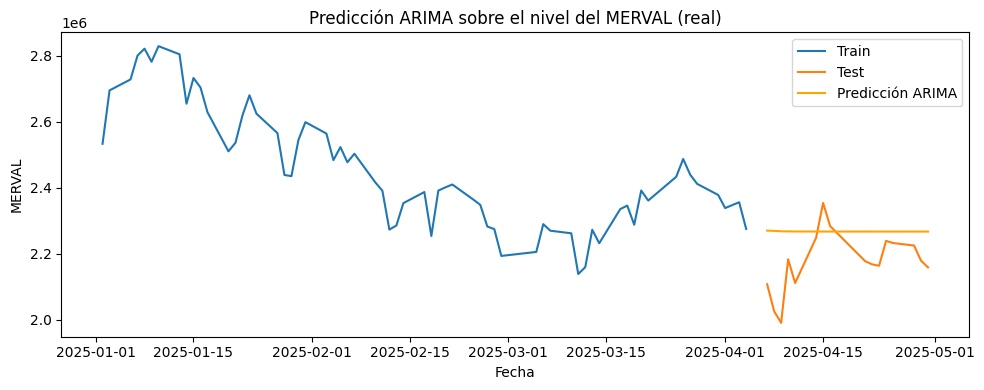

In [19]:
# ============================================================
# 3. AJUSTE DEL MODELO ARIMA
# ============================================================

# Entrenar directamente sobre niveles; ARIMA hará la diferenciación interna
model = ARIMA(train, order=(2, 1, 2))
res = model.fit()

# ============================================================
# 4. PRONÓSTICO Y EVALUACIÓN (en niveles reales)
# ============================================================

# Pronóstico en niveles
start = len(train)
end = len(train) + len(test) - 1
forecast = res.predict(start=start, end=end, typ="levels")

# Alinear índice
forecast.index = test.index

# Calcular RMSE
rmse = root_mean_squared_error(test, forecast)
print(f"Holdout RMSE (ARIMA, nivel MERVAL): {rmse:,.4f}")

# ============================================================
# 5. VISUALIZACIÓN
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(train.index.to_timestamp(), train, label="Train")
plt.plot(test.index.to_timestamp(), test, label="Test")
plt.plot(forecast.index.to_timestamp(), forecast, label="Predicción ARIMA", color="orange")
plt.title("Predicción ARIMA sobre el nivel del MERVAL (real)")
plt.xlabel("Fecha")
plt.ylabel("MERVAL")
plt.legend()
plt.tight_layout()
plt.show()